# This file replicates the findings using spike triggered analysis

In [1]:
import scipy
from utility_functions import *
import matplotlib.pyplot as plt
from sklearn.decomposition import FactorAnalysis
import matplotlib.colors as mcolors
from sklearn.cluster import KMeans

plt.rcParams["axes.linewidth"] = 2
plt.rcParams["axes.edgecolor"] = 'k'
plt.rcParams['grid.alpha'] = 0

# Load the data and meta data
 Here we are looking into the spike triggered average analysis. To calculate the factor weights we need to use the whole trial. So `data_type` should be "STA" and "trials".

In [2]:
data_type='STA' # this could be 'trials', 'last4s', 'first4s','STA'.
monkey='C' # monkey should be one of 'C', 'J' or 'M'
CE=63 # channel name. NOTE: this is not the channel number or the channel index

# load the grid layout of the monkey
grid=get_grid(monkey)
# load the spike channel number
spike_channel=get_channel(monkey,CE)
# load the location of the CE on the grid
loc_x,loc_y=get_CE_loc(grid,spike_channel)
# load the shunted electrodes for this monkey. This is the python index
shunted_electrodes=load_shunted_electrodes(monkey,spike_channel)
# finally, load the raw data
STA_data=load_STA_data(data_type, monkey, CE)

In [3]:
# This data store the spike train and filtered high gamma band analytical signals.
STA_data

,spike,HGA
0,"[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[1.3353907941468715, 1.2383201009968918, -1.5..."
1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[-0.05215323024877066, 1.3453591959090863, 0...."
2,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[-0.3148718932790695, -0.8206791235121531, 0...."
3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[-1.1877893606713568, -0.53771699042728, 1.31..."
4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.20381970340986832, -0.8432876743853872, -0..."
5,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[-1.1598733408252142, -1.5994442690000128, 0...."
6,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[-0.8095561370273622, -1.2465739525269268, 1...."
7,"[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[-0.6347944795448246, 0.7288277843653892, 0.4..."
8,"[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.9429503997256172, -0.586913383131681, -1.1..."
9,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[1.6116421430628354, -0.6729651875228413, -2...."


In [4]:
spike=STA_data['spike'].to_numpy()
HGA=STA_data['HGA'].to_numpy()

spike_flat=np.concatenate(spike,axis=-1)
HGA_flat=np.concatenate(HGA,axis=-1)

## Preprocessing of the data

In [5]:
n_time=spike_flat.shape[-1]
leftover_electrode_list=np.arange(0,spike_flat.shape[0])
print(f"Original data shape (chan x time): {spike_flat.shape}")

# take out the shunted electrodes
spike_flat=np.delete(spike_flat,shunted_electrodes,axis=0)
HGA_flat=np.delete(HGA_flat,shunted_electrodes,axis=0)
leftover_electrode_list=np.delete(leftover_electrode_list,shunted_electrodes)
print(f"Took out the shunted electrodes, data shape (chan x time): {spike_flat.shape}")

# take out electrodes that contain NAN
has_nan_spike=np.sum(np.isnan(spike_flat),axis=-1)
has_nan_HGA=np.sum(np.isnan(HGA_flat),axis=-1)
has_nan=np.where(has_nan_HGA+has_nan_spike)
spike_flat=np.delete(spike_flat,has_nan,axis=0)
HGA_flat=np.delete(HGA_flat,has_nan,axis=0)
leftover_electrode_list=np.delete(leftover_electrode_list,has_nan)
print(f"Took out the electrodes containing NAN values, data shape (chan x time): {spike_flat.shape}")

# locate the index of the control electrode
CE_index=np.where(leftover_electrode_list==spike_channel-1)[0]

spike=[spike[i][leftover_electrode_list,:] for i in range(len(spike))]
HGA=[HGA[i][leftover_electrode_list,:] for i in range(len(HGA))]

Original data shape (chan x time): (96, 1492254)
Took out the shunted electrodes, data shape (chan x time): (71, 1492254)
Took out the electrodes containing NAN values, data shape (chan x time): (62, 1492254)


## Calculate the first factor weight for visualization

In [6]:
# bin the spikes to 50ms and do factor analysis
# note that the spike data has 1ms resolution
def bin_data(spike_data,binsize):
    n_chan,data_length=spike_data.shape
    binned_length=data_length//binsize*binsize
    trimmed_spike_data=spike_data[:,:binned_length]
    binned_spike_data=trimmed_spike_data.reshape(n_chan,data_length//binsize,binsize).mean(axis=-1)
    return np.squeeze(binned_spike_data)
binned_spikes=[bin_data(s,50) for s in spike]
spike_rate=np.concatenate(binned_spikes,axis=1)
spike_rate_zscored=(spike_rate-spike_rate.mean())/spike_rate.std() # this is used for factor weights

In [7]:
fa=FactorAnalysis(n_components=1)
fa.fit(spike_rate_zscored.T)
weights=np.abs(fa.components_)
normalized_weights=(weights-weights.min())/(weights.max()-weights.min())

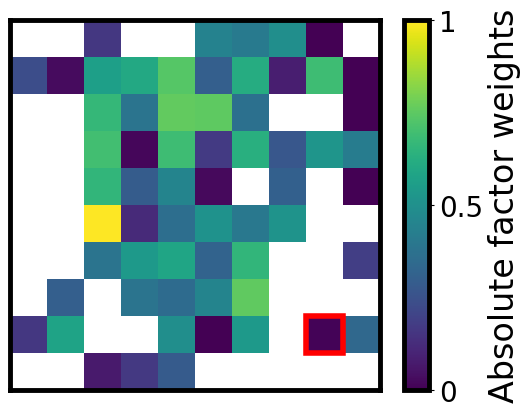

In [8]:
fig,ax=plt.subplots(1,1)
im=plot_on_grid(ax,
                leftover_electrode_list,
                grid,normalized_weights,
                (loc_x,loc_y),
                show_chan_indx=False,
                cmap=mpb.cm.viridis,
                CE_color='r')
clim=np.max(np.abs(normalized_weights))
ax.spines[['left','right','top','bottom']].set_linewidth(3.5)
ax.spines[['left','right','top','bottom']].set_color('k')
im.set_clim(0,clim)

cbar=fig.colorbar(im,aspect=15)

# Set the colorbar label text
cbar.set_label('Absolute factor weights', fontsize=24)
cbar.outline.set_linewidth(3.5)
cbar.outline.set_color('k')
# Set the colorbar ticks and tick labels
cbar.set_ticks([0, clim/2, clim])
cbar.set_ticklabels(['0','0.5','1'],fontsize=20)
plt.show()

## Calculate the spike triggered averages

In [9]:
# event triggered averages plotted on each electrode
spike_loc=np.array(np.where(np.concatenate(spike,axis=-1)==1)) # find the spike time
# not counting the spikes that are too close to the beginning or end +-1s.
spike_loc=np.delete(spike_loc,np.where((spike_loc[1,:]>(HGA_flat.shape[1]-1000))|(spike_loc[1,:]<1000))[0],axis=1)

HGA_sta=[]
for i in np.unique(spike_loc[0,:]): # looping through the electrodes
    time_ind=spike_loc[:,np.where(spike_loc[0]==i)[0]]
    time_ind=time_ind[1,:][:,None]-50+np.arange(120) # 50 ms before the event and 70 ms after the event

    # take out the CE HGA STAs
    corresponding_HGA=HGA_flat[CE_index,time_ind]
    HGA_sta.append(corresponding_HGA.mean(axis=0))

plotting

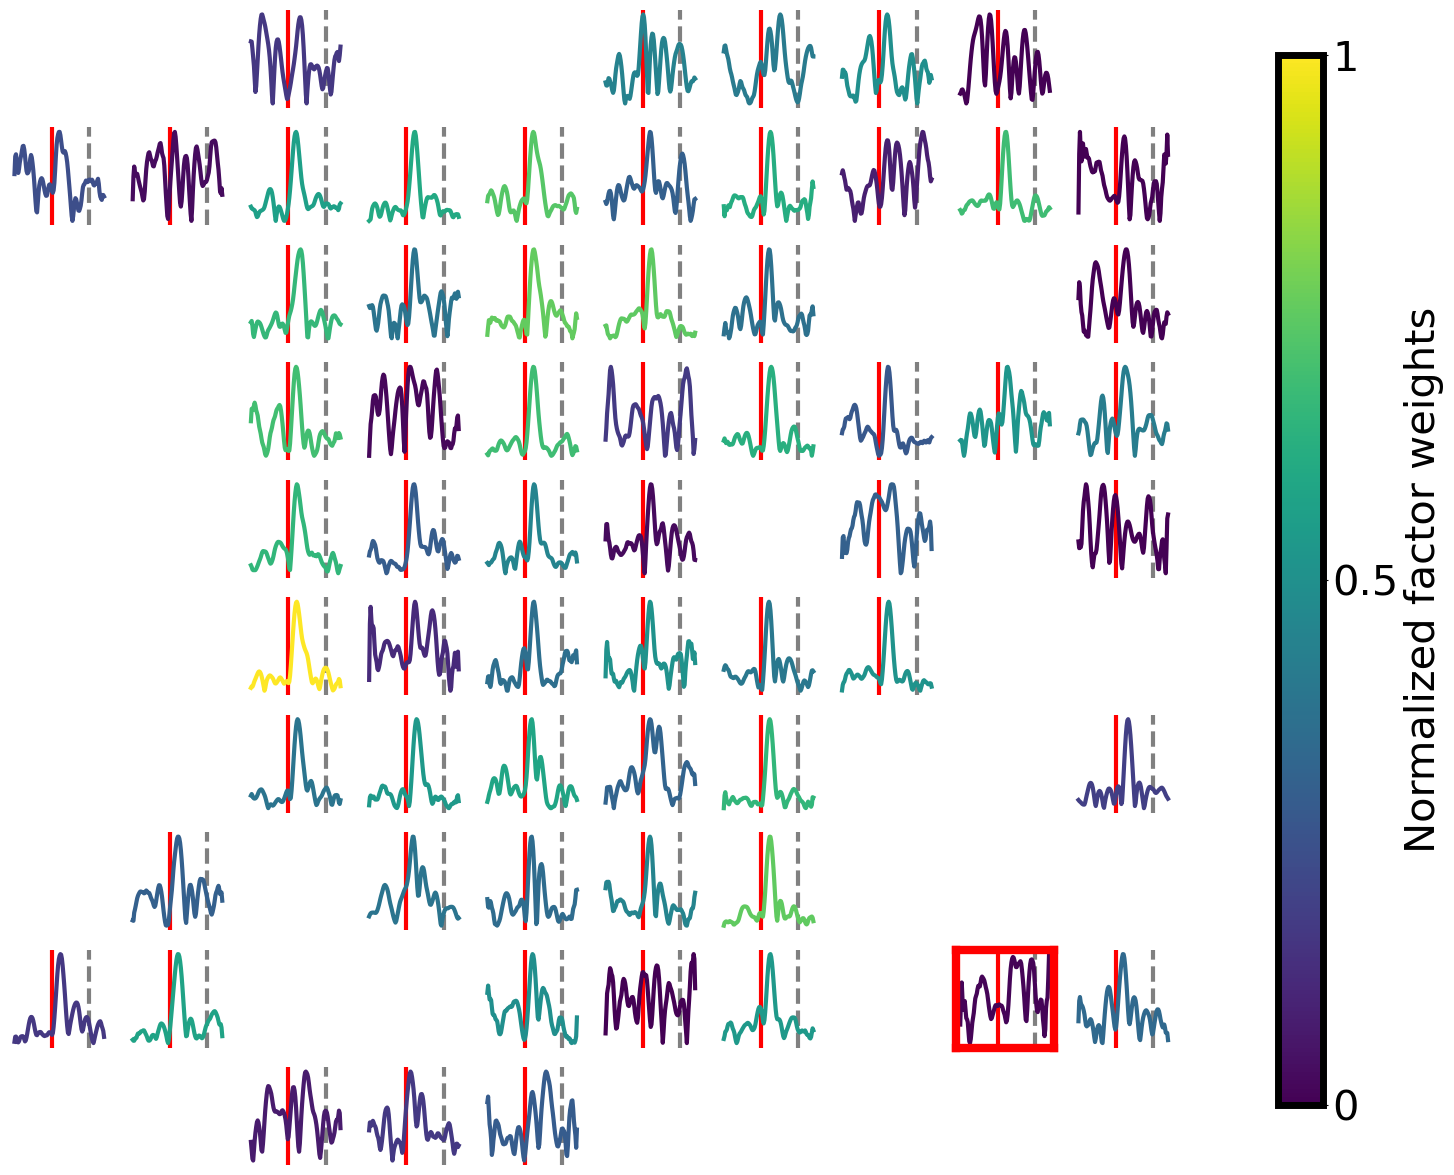

In [10]:
# mapping the data to the grid
flat=grid.flatten()
full_electrode = np.empty(96)
full_electrode[:] = np.nan
full_electrode[leftover_electrode_list] = leftover_electrode_list
elec = []

for i in range(100):
    if flat[i]:  # or i!=0 or i!=9 or i!=90 or i!=99:
        elec.append(full_electrode[flat[i] - 1])  # turn in to python index
    else:
        elec.append(np.NaN)
elec = np.reshape(elec, [10, 10])

# color the STA using the factor weights
color_source=normalized_weights
colormap=plt.cm.viridis
norm=mcolors.Normalize(vmin=0,vmax=clim)
cc_colors=np.squeeze(colormap(norm(color_source)))


######### plotting STAs on each electrode ################
fig,ax=plt.subplots(10,10,figsize=(15,15))

j=0
x=np.linspace(-0.05,0.07,120)
for i in range(100):
    ax[i//10,i%10].axis('off')
    loc=np.where(elec==i)
    if i in leftover_electrode_list:
        # plot 0 ms: spike time
        ax[loc[0][0],loc[1][0]].axvline(0,color='red',lw=3)
        # plot 20 ms after the spike time
        ax[loc[0][0],loc[1][0]].axvline(0.05,color='grey',linestyle='--',lw=3)
        # plot the STA
        ax[loc[0][0],loc[1][0]].plot(x,np.abs(scipy.signal.hilbert(HGA_sta[j])),lw=3,color=cc_colors[j])

        # beautification of the plot
        ax[loc[0][0],loc[1][0]].axis("on")
        ax[loc[0][0],loc[1][0]].set_xticks([])
        ax[loc[0][0],loc[1][0]].set_yticks([])
        ax[loc[0][0],loc[1][0]].spines['top'].set_linewidth(0)
        ax[loc[0][0],loc[1][0]].spines['bottom'].set_linewidth(0)
        ax[loc[0][0],loc[1][0]].spines['left'].set_linewidth(0)
        ax[loc[0][0],loc[1][0]].spines['right'].set_linewidth(0)

        j+=1

# more beautification
ax[loc_x,loc_y].axis("on")
ax[loc_x,loc_y].set_xticks([])
ax[loc_x,loc_y].set_yticks([])
ax[loc_x,loc_y].spines['top'].set_linewidth(6)
ax[loc_x,loc_y].spines['bottom'].set_linewidth(6)
ax[loc_x,loc_y].spines['left'].set_linewidth(6)
ax[loc_x,loc_y].spines['right'].set_linewidth(6)
ax[loc_x,loc_y].spines['top'].set_color('r')
ax[loc_x,loc_y].spines['bottom'].set_color('r')
ax[loc_x,loc_y].spines['left'].set_color('r')
ax[loc_x,loc_y].spines['right'].set_color('r')
cbar_ax =fig.add_axes([0.97, 0.15, 0.03, 0.7])
cb=fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.viridis), cax=cbar_ax)
cb.set_label('Normalized factor weights',fontsize=30)
cb.outline.set_linewidth(5)
# Set the colorbar ticks and tick labels
cb.set_ticks([0, clim/2, clim])
cb.set_ticklabels(['0','0.5','1'],fontsize=30)
plt.show()

## Plot the same data in another way to show consistent STA timings across electrodes

The mean of peak time is 10.10 ms, confidence interval of the response time is 5.51 - 14.68 ms


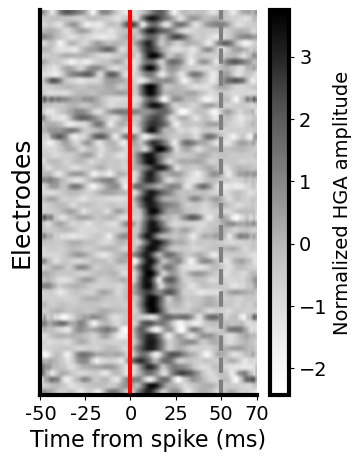

In [11]:
fig,ax=plt.subplots(1,1,figsize=(3.5,5))
HGA_sta_to_plot=scipy.stats.zscore(np.abs(scipy.signal.hilbert(HGA_sta,axis=1)),axis=1)

# here we insert the peak detection
peaks=np.argmax(HGA_sta_to_plot,axis=1)
# calculate the peak time in relation to the spike time
peaks_mean=peaks.mean()-50
peaks_std=peaks.std()

# calculate the confidence interval
# Sample size
n = len(HGA_sta_to_plot)
# Confidence level
confidence_level = 0.95
alpha = 1 - confidence_level
# Critical value (Z-score)
Z = scipy.stats.norm.ppf(1 - alpha/2)
# Margin of error
E = Z * (peaks_std / np.sqrt(n))
# Confidence interval
CI_lower = peaks_mean - E
CI_upper = peaks_mean + E
print(f"The mean of peak time is {peaks_mean:0.2f} ms, confidence interval of the response time is {CI_lower:0.2f} - {CI_upper:0.2f} ms")

im=ax.imshow(HGA_sta_to_plot,cmap=plt.cm.Greys,aspect='auto')
ax.axvline(50,lw=3,color='red')
ax.axvline(100,lw=3,color='grey',linestyle='--')
ax.set_xticks([0,25,50,75,100,120],[-50,-25,0,25,50,70],fontsize=14)
ax.set_xlabel("Time from spike (ms)",fontsize=16)
ax.set_yticks([])
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(3)
ax.set_ylabel("Electrodes",fontsize=18)
cbar = fig.colorbar(im)
# Adjust the thickness of the colorbar outline
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(3)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Normalized HGA amplitude', fontsize=14)

plt.show()

## K-mean clustering the STA responses into two groups, colored by factor weights

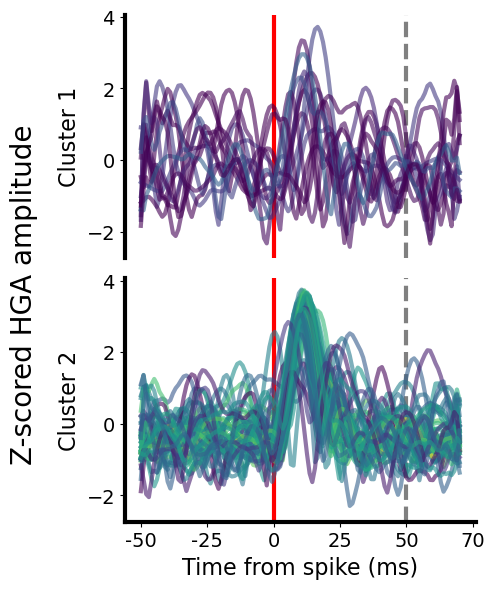

In [12]:
data=HGA_sta
data=(data-np.nanmean(data,axis=1)[:,None])/np.nanstd(data,axis=1)[:,None]

########## KMeans clustering #########
n_clusters=2
km=KMeans(n_clusters=n_clusters,n_init='auto',algorithm='elkan')
km.fit(data)
group=km.labels_

data=np.abs(scipy.signal.hilbert(np.array(HGA_sta),axis=1))
data_to_plot=(data-np.nanmean(data,axis=1)[:,None])/np.nanstd(data,axis=1)[:,None]
fig,ax=plt.subplots(n_clusters,1,figsize=(5,(n_clusters)*3),sharey=True)
for group_ind in range(n_clusters):
    group_loc=np.where(group==group_ind)
    HGA_eta_group=np.array(data_to_plot)[group_loc[0]]
    HGA_eta_group=(HGA_eta_group-np.nanmean(HGA_eta_group,axis= 1)[:,None])/np.nanstd(HGA_eta_group,axis=1)[:,None]#(HGA_eta_group.max(axis=0)[None,:]-HGA_eta_group.min(axis=0)[None,:])

    # calculate the peak time
    # here we insert the peak detection
    peaks=np.argmax(HGA_eta_group,axis=1)
    peaks_mean=peaks.mean()
    peaks_std=peaks.std()

    ax[n_clusters-group_ind-1].axvline(0,color='red',lw=3)
    ax[n_clusters-group_ind-1].axvline(0.05,color='grey',lw=3,linestyle='--')
    ax[n_clusters-group_ind-1].set_xticks([])
    ax[n_clusters-group_ind-1].tick_params(axis='y', labelsize=14)
    lines=ax[n_clusters-group_ind-1].plot(np.tile(x,(HGA_eta_group.shape[0],1)).T,HGA_eta_group.T,lw=3,alpha=0.6)
    ax[n_clusters-group_ind-1].spines[['right', 'top', 'bottom']].set_visible(False)
    ax[n_clusters-group_ind-1].spines['left'].set_linewidth(3)
    ax[n_clusters-group_ind-1].set_ylabel(f'Cluster {n_clusters-group_ind}',fontsize=16)
    for idx, color in enumerate(cc_colors[group_loc[0]]):
        lines[idx].set_color(color)
ax[-1].spines['bottom'].set_visible(True)
ax[-1].spines['bottom'].set_linewidth(3)
ax[-1].set_xticks([-0.05,-0.025,0,0.025,0.05,0.075],[-50,-25,0,25,50,70],fontsize=14)
ax[-1].set_xlabel("Time from spike (ms)",fontsize=16)
fig.supylabel('Z-scored HGA amplitude',fontsize=20)
plt.tight_layout()
plt.show()

## Test if the factor weights in the two clusters are significantly different

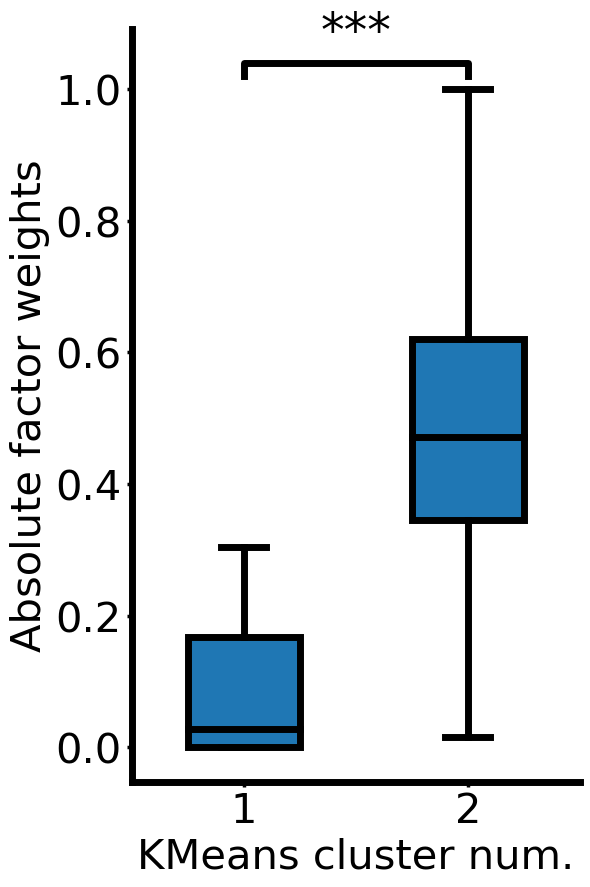

In [13]:
spine_width=5
text_fontsize=34
line_width=5
box_line_width=5
box_size=0.2
label_size=30

weights=np.squeeze(normalized_weights)
group_loc_1=np.where(group==0)
weights_1=weights[group_loc_1[0]]

group_loc_2=np.where(group==1)
weights_2=weights[group_loc_2[0]]

weights_max=weights.max()
_,p=scipy.stats.mannwhitneyu(weights_1,weights_2) # since the weights are bounded from 0,1, we used a nonparametric test
fig,ax=plt.subplots(1,1,figsize=(6,9))
ax.boxplot([weights_2,weights_1],patch_artist=True,
           widths=0.5,capwidths=box_size,
           boxprops=dict(facecolor='tab:blue', linewidth=box_line_width),
           medianprops=dict(color='black', linewidth=box_line_width),
           whiskerprops=dict(linewidth=box_line_width),
           capprops=dict(linewidth=box_line_width),
           showfliers=False)
ax.plot(
        [1, 1, 2, 2],
        [weights_max*1.02,weights_max*1.04, weights_max*1.04, weights_max*1.02], lw=line_width, c='k'
    )
ax.text(1.5, weights_max*1.05,get_the_star(p), ha='center', va='bottom', c='k',size=text_fontsize)
ax.set_ylabel("Absolute factor weights",fontsize=label_size)
ax.set_xlabel("KMeans cluster num.",fontsize=label_size)
ax.set_xticks(ticks=[1,2], labels=['1', '2'],fontsize=label_size)
ax.tick_params(labelsize=label_size,width=2.5)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left','bottom']].set_linewidth(spine_width)
plt.tight_layout()
plt.show()